In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
data = pd.read_csv('IRIS.csv')

In [4]:
data.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
data.shape

(150, 5)

In [6]:
data.isnull().sum()

sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [8]:
data.describe()

,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


In [10]:
from sklearn.preprocessing import LabelEncoder
from pandas.core.dtypes.common import is_numeric_dtype
le = LabelEncoder()

In [11]:
for i in data.columns:
    if is_numeric_dtype(data[i]):
        continue
    else:
        data[i] = le.fit_transform(data[i])

In [12]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


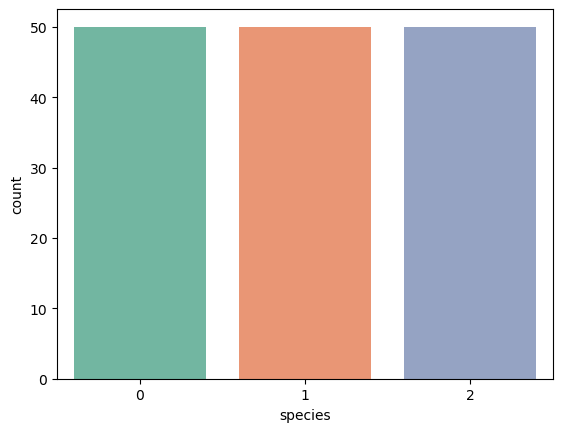

In [15]:
sns.countplot(
    x='species',
    hue='species',
    data=data,
    palette='Set2',
    legend=False
)
plt.show()

<Axes: xlabel='sepal_length', ylabel='Count'>

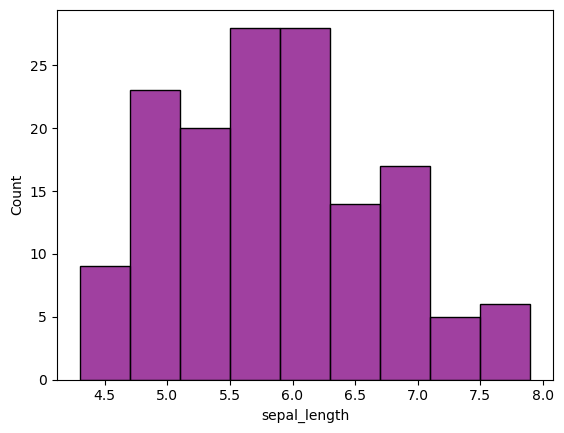

In [16]:
sns.histplot(data = data, x = data.sepal_length , color ='purple')

<Axes: xlabel='sepal_width', ylabel='Count'>

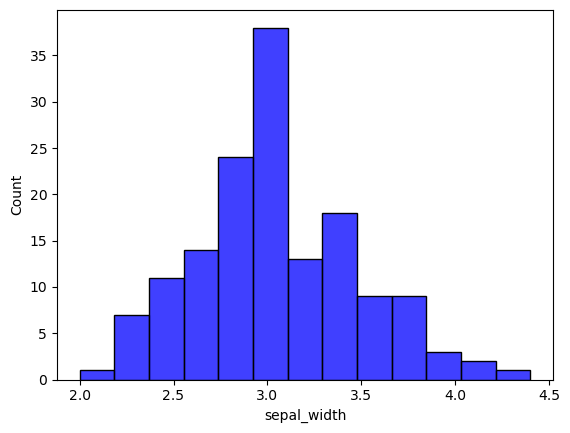

In [18]:
sns.histplot(data = data, x = data.sepal_width , color ='blue')

<Axes: xlabel='petal_length', ylabel='Count'>

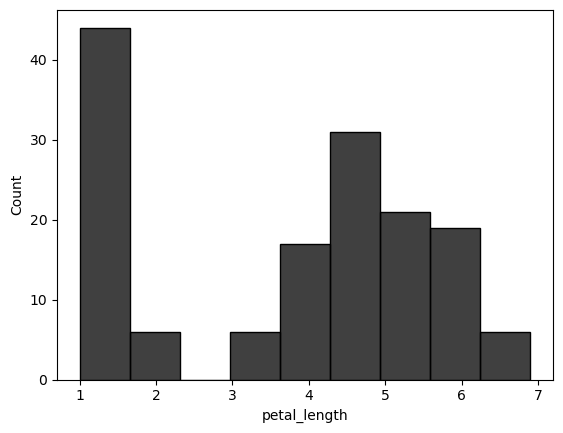

In [19]:
sns.histplot(data = data, x = data.petal_length , color ='black')

<Axes: xlabel='petal_width', ylabel='Count'>

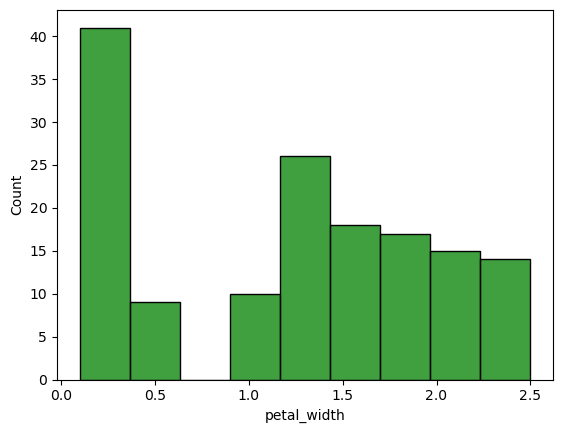

In [21]:
sns.histplot(data = data, x = data.petal_width , color ='green') 

<Axes: >

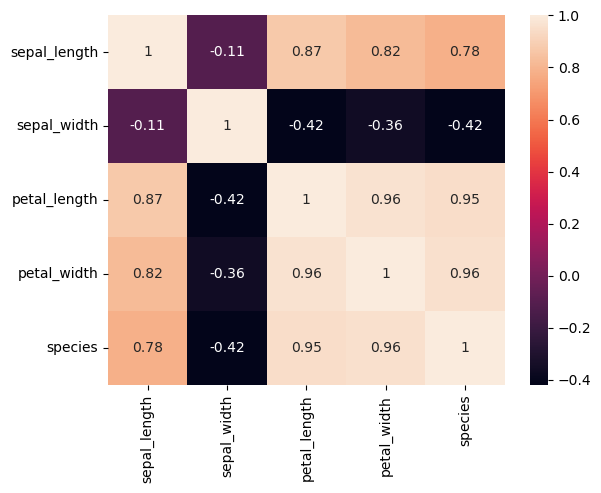

In [23]:
corr = data.corr()
sns.heatmap(corr, annot = True)

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
data.columns

Index(['sepal_length', 'sepal_width', 'petal_length', 'petal_width',
       'species'],
      dtype='object')

In [27]:
X = data.drop(['species'],axis=1)
y = data.species

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3)

In [30]:
from sklearn.linear_model import LogisticRegression

In [37]:
Model = LogisticRegression()
Model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [38]:
print("Score for Train data",Model.score(X_train, y_train))
print("Score for Test data",Model.score(X_test, y_test))

Score for Train data 0.9809523809523809
Score for Test data 0.9555555555555556


In [42]:
from sklearn.ensemble import RandomForestClassifier

Model2 = RandomForestClassifier(n_estimators = 300, random_state=50)
Model2.fit(X_train,y_train)

,n_estimators,300
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [43]:
print("Score for Train data",Model2.score(X_train, y_train))
print("Score for Test data",Model2.score(X_test, y_test))

Score for Train data 1.0
Score for Test data 0.9333333333333333


In [44]:
from sklearn.neighbors import KNeighborsClassifier

Model3 = KNeighborsClassifier()
Model3.fit(X_train,y_train)


,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [45]:
print("Score for Train data",Model3.score(X_train, y_train))
print("Score for Test data",Model3.score(X_test, y_test))

Score for Train data 0.9904761904761905
Score for Test data 0.9555555555555556


In [48]:
# for testing create new dataframe with values close to the our existing data


In [51]:
data = {'sepal_length': [5.2],'sepal_width':[3.6],'petal_length':[1.4],'petal_width':[0.2]}
trail = pd.DataFrame(data)

In [52]:
result = Model.predict(trail)
print("Result species:",result[0])

Result species: 0
